# Perturbation features for train / val / test selection

For every **genetic perturbation** (gene knockout) we compute three features that we will use to
diversify the perturbation test set and to report how ablation results depend on perturbation
properties:

1. **Power — number of cells per perturbation in each drug context.**
   Counted from the per-drug pathway caches
   (`ChemoGenetic_H1_Basak_Pathways/<drug>.h5ad`, `obs['target_gene']`). BuildDrugCaches keeps *every*
   perturbed cell (only `non-targeting` controls are subsampled), so these are the true KO cell counts.

2. **Effect size — number of DE genes per drug context.**
   From the per-drug FDR matrices (`FDR_matrices/<drug>_FDRs.csv`, perturbations × response genes),
   counting response genes with **FDR < 0.01** per perturbation.

3. **Context specificity — per perturbation.**
   From `23_ContextSpecificity_vs_PCs.ipynb` / `18_PerturbationManifoldMotion.ipynb`: per gene, the
   **mean cosine distance** between each `(drug, gene)` signature and the **same gene's batch-matched
   DMSO** signature (`batch1→DMSO_round2`, `batch2→DMSO_round2_batch2`), averaged over non-DMSO drug
   contexts, computed in the first **250 PCs**. Higher ⇒ the KO's effect changes more across drug
   backgrounds ⇒ **more context-specific**.

**Outputs:** per-(gene × drug) matrices for features 1–2, a per-gene context-specificity table, and a
combined per-perturbation feature table for the downstream split.

> Note: context specificity here is the cosine-distance-to-batch-matched-DMSO score at 250 PCs (notebook
> 23). See the printed Spearman correlations below for how it relates to power and effect size in this
> dataset, and treat it conditional on adequate power/effect size when diversifying the test set.

In [1]:
import os, glob, time
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# ---- Parameters ---------------------------------------------------------
projectDir = "/home/beraslan/Projects/ChemoGeneticScreens"
CACHE_DIR  = "/processed_datasets/VCI/ChemoGenetic_H1_Basak_Pathways"   # per-drug caches w/ target_gene
FDR_DIR    = os.path.join(projectDir, "FDR_matrices")                    # <drug>_FDRs.csv
# Context specificity = cosine distance to batch-matched DMSO at 250 PCs (notebook 23 / 18)
CONTEXT_SPEC_NPCS = 250
MOTION_CSV = os.path.join(projectDir, "PerturbationEmbeddings", "pc_sweep",
                          "context_specificity_motion_by_npcs_pergene.csv")

FDR_THRESH   = 0.01
CONTROL_LABEL = "non-targeting"
# clustering of perturbations on their combined features
N_NEIGHBORS = 15
LEIDEN_RES  = 1.0

OUT_DIR = os.path.join(projectDir, "TextFiles")
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
# ===== Feature 1: cells per perturbation per drug context ================
cache_files = sorted(glob.glob(os.path.join(CACHE_DIR, "*.h5ad")))
print(f"{len(cache_files)} drug caches")
cell_counts = {}
for f in cache_files:
    drug = os.path.basename(f)[:-5]
    t = time.time()
    a = sc.read_h5ad(f, backed="r")
    vc = a.obs["target_gene"].astype(str).value_counts()
    vc = vc.drop(CONTROL_LABEL, errors="ignore")
    cell_counts[drug] = vc
    print(f"  {drug:<22s} {a.n_obs:>9,d} cells, {len(vc):>4d} perts   [{time.time()-t:.1f}s]")

cells_per_drug = pd.DataFrame(cell_counts).fillna(0).astype(int).sort_index()
cells_per_drug.index.name = "gene"
cells_per_drug.to_csv(os.path.join(OUT_DIR, "perturbation_cells_per_drug.csv"))
print("cells_per_drug:", cells_per_drug.shape, "(genes x drug contexts)")
cells_per_drug.head()

16 drug caches
  AR-A014418             1,929,725 cells, 2367 perts   [2.0s]
  AZD4573                1,912,730 cells, 2325 perts   [1.9s]
  Bisindolylmaleimide-I  2,109,294 cells, 2338 perts   [2.0s]
  CHIR-98014             2,106,394 cells, 2289 perts   [2.1s]
  DG-172                 2,303,839 cells, 2381 perts   [2.3s]
  DMSO_round2            1,494,952 cells, 2281 perts   [1.3s]
  DMSO_round2_batch2     1,524,330 cells, 2290 perts   [1.3s]
  JTE-607                1,562,345 cells, 2408 perts   [1.4s]
  LDN-193189             2,437,876 cells, 2357 perts   [2.3s]
  LY2090314              2,081,571 cells, 2257 perts   [2.0s]
  Lexibulin              2,295,127 cells, 2367 perts   [2.2s]
  NSC95397               2,508,039 cells, 2351 perts   [2.4s]
  PP121                  2,006,968 cells, 2321 perts   [1.9s]
  Romidepsin             1,577,934 cells, 2378 perts   [1.4s]
  Stattic                2,371,676 cells, 2370 perts   [2.2s]
  VX-11e                 1,430,453 cells, 2360 perts   

,AR-A014418,AZD4573,Bisindolylmaleimide-I,CHIR-98014,DG-172,DMSO_round2,DMSO_round2_batch2,JTE-607,LDN-193189,LY2090314,Lexibulin,NSC95397,PP121,Romidepsin,Stattic,VX-11e
gene,,,,,,,,,,,,,,,,
A1BG,2540,2611,2782,2804,2958,2089,2166,2123,3232,2874,3002,3235,2653,1978,3275,1900
AASS,923,925,961,962,1055,659,659,719,999,1034,1141,1082,912,749,1018,653
AATF,0,1,0,0,0,0,1,4,1,0,0,1,0,2,1,0
ABCB6,1442,1437,1621,1662,1921,1117,1134,1197,1820,1744,1717,1894,1637,1225,1871,981
ABCC5,1086,1159,1182,1384,1394,863,903,668,1441,1223,1310,1435,1106,812,1466,769


  VX-11e                 1,430,453 cells, 2360 perts   [1.2s]
cells_per_drug: (2478, 16) (genes x drug contexts)


,AR-A014418,AZD4573,Bisindolylmaleimide-I,CHIR-98014,DG-172,DMSO_round2,DMSO_round2_batch2,JTE-607,LDN-193189,LY2090314,Lexibulin,NSC95397,PP121,Romidepsin,Stattic,VX-11e
gene,,,,,,,,,,,,,,,,
A1BG,2540,2611,2782,2804,2958,2089,2166,2123,3232,2874,3002,3235,2653,1978,3275,1900
AASS,923,925,961,962,1055,659,659,719,999,1034,1141,1082,912,749,1018,653
AATF,0,1,0,0,0,0,1,4,1,0,0,1,0,2,1,0
ABCB6,1442,1437,1621,1662,1921,1117,1134,1197,1820,1744,1717,1894,1637,1225,1871,981
ABCC5,1086,1159,1182,1384,1394,863,903,668,1441,1223,1310,1435,1106,812,1466,769


In [3]:
# ===== Feature 2: DE genes per perturbation per drug context (FDR<0.01) ==
fdr_files = sorted(glob.glob(os.path.join(FDR_DIR, "*_FDRs.csv")))
print(f"{len(fdr_files)} FDR matrices (threshold FDR < {FDR_THRESH})")
de_counts = {}
for f in fdr_files:
    drug = os.path.basename(f).replace("_FDRs.csv", "")
    t = time.time()
    m = pd.read_csv(f, index_col=0)
    de_counts[drug] = (m < FDR_THRESH).sum(axis=1)
    print(f"  {drug:<22s} {m.shape[0]:>4d} perts x {m.shape[1]:>5d} genes   [{time.time()-t:.1f}s]")

# NaN where a gene was not tested in that context (kept distinct from 0 DE)
de_per_drug = pd.DataFrame(de_counts).sort_index()
de_per_drug.index.name = "gene"
de_per_drug.to_csv(os.path.join(OUT_DIR, f"perturbation_nDE_fdr_lt_{str(FDR_THRESH).replace('.','p')}_per_drug.csv"))
print("de_per_drug:", de_per_drug.shape, "(genes x drug contexts)")
de_per_drug.head()

17 FDR matrices (threshold FDR < 0.01)
  AR-A014418             2367 perts x 18154 genes   [10.5s]
  AZD4573                2325 perts x 18154 genes   [10.7s]
  Bisindolylmaleimide-I  2338 perts x 18154 genes   [10.6s]
  CHIR-98014             2289 perts x 18154 genes   [10.3s]
  DG-172                 2381 perts x 18154 genes   [10.9s]
  DMSO                   2334 perts x 18151 genes   [10.3s]
  DMSO_round2            2281 perts x 18154 genes   [10.1s]
  DMSO_round2_batch2     2290 perts x 18154 genes   [9.9s]
  JTE-607                2408 perts x 18154 genes   [11.0s]
  LDN-193189             2330 perts x 18154 genes   [10.4s]
  LY2090314              2257 perts x 18154 genes   [9.8s]
  Lexibulin              2367 perts x 18154 genes   [10.8s]
  NSC95397               2139 perts x 18154 genes   [9.5s]
  PP121                  2321 perts x 18154 genes   [10.1s]
  Romidepsin             2378 perts x 18154 genes   [10.6s]
  Stattic                2370 perts x 18154 genes   [10.8s]
  VX

,AR-A014418,AZD4573,Bisindolylmaleimide-I,CHIR-98014,DG-172,DMSO,DMSO_round2,DMSO_round2_batch2,JTE-607,LDN-193189,LY2090314,Lexibulin,NSC95397,PP121,Romidepsin,Stattic,VX-11e
gene,,,,,,,,,,,,,,,,,
A1BG,61.0,35.0,39.0,90.0,50.0,28.0,46.0,46.0,59.0,30.0,53.0,36.0,54.0,41.0,48.0,42.0,52.0
AASS,135.0,84.0,113.0,117.0,106.0,73.0,61.0,65.0,76.0,110.0,84.0,113.0,102.0,92.0,84.0,119.0,66.0
AATF,NaN,89.0,NaN,NaN,NaN,NaN,NaN,86.0,90.0,62.0,NaN,NaN,65.0,NaN,36.0,161.0,NaN
ABCB6,76.0,55.0,71.0,1418.0,71.0,40.0,64.0,51.0,91.0,51.0,1382.0,54.0,99.0,45.0,71.0,111.0,49.0
ABCC5,69.0,51.0,42.0,79.0,59.0,43.0,61.0,60.0,92.0,44.0,64.0,62.0,70.0,62.0,70.0,56.0,48.0


  Stattic                2370 perts x 18154 genes   [11.1s]


  VX-11e                 2360 perts x 18154 genes   [10.6s]
de_per_drug: (2478, 17) (genes x drug contexts)


,AR-A014418,AZD4573,Bisindolylmaleimide-I,CHIR-98014,DG-172,DMSO,DMSO_round2,DMSO_round2_batch2,JTE-607,LDN-193189,LY2090314,Lexibulin,NSC95397,PP121,Romidepsin,Stattic,VX-11e
gene,,,,,,,,,,,,,,,,,
A1BG,61.0,35.0,39.0,90.0,50.0,28.0,46.0,46.0,59.0,30.0,53.0,36.0,54.0,41.0,48.0,42.0,52.0
AASS,135.0,84.0,113.0,117.0,106.0,73.0,61.0,65.0,76.0,110.0,84.0,113.0,102.0,92.0,84.0,119.0,66.0
AATF,NaN,89.0,NaN,NaN,NaN,NaN,NaN,86.0,90.0,62.0,NaN,NaN,65.0,NaN,36.0,161.0,NaN
ABCB6,76.0,55.0,71.0,1418.0,71.0,40.0,64.0,51.0,91.0,51.0,1382.0,54.0,99.0,45.0,71.0,111.0,49.0
ABCC5,69.0,51.0,42.0,79.0,59.0,43.0,61.0,60.0,92.0,44.0,64.0,62.0,70.0,62.0,70.0,56.0,48.0


In [4]:
# ===== Feature 3: context specificity = cosine distance to batch-matched DMSO (250 PCs) ====
# From notebook 23: per gene, the mean cosine distance between each (drug, gene) signature and the
# same gene's batch-matched DMSO baseline, over non-DMSO drug contexts, using the first
# CONTEXT_SPEC_NPCS PCs. One value per genetic perturbation.
_motion = pd.read_csv(MOTION_CSV, index_col=0)
_motion.columns = _motion.columns.astype(str)
assert str(CONTEXT_SPEC_NPCS) in _motion.columns, f"{CONTEXT_SPEC_NPCS} not in {list(_motion.columns)}"

ctx = pd.DataFrame(index=_motion.index)
ctx.index.name = "gene"
ctx["context_specificity"] = _motion[str(CONTEXT_SPEC_NPCS)]   # mean cosine distance to batch-matched DMSO
ctx = ctx.dropna(subset=["context_specificity"]).sort_values("context_specificity", ascending=False)
ctx.to_csv(os.path.join(OUT_DIR, "perturbation_context_specificity.csv"))
print(f"context specificity (cosine-to-DMSO, {CONTEXT_SPEC_NPCS} PCs) per gene:", ctx.shape)
print("  most context-specific:", list(ctx.head(5).index))
print("  least context-specific:", list(ctx.tail(5).index))
ctx.head()

context specificity (cosine-to-DMSO, 250 PCs) per gene: (1919, 1)
  most context-specific: ['MTA2', 'NPM1', 'RALGDS', 'TAZ', 'CAMTA2']
  least context-specific: ['SP2', 'MPHOSPH8', 'REST', 'TMED10', 'MORC2']


,context_specificity
gene,
MTA2,0.886716
NPM1,0.865489
RALGDS,0.808381
TAZ,0.806290
CAMTA2,0.798327


In [5]:
cells_per_drug

,AR-A014418,AZD4573,Bisindolylmaleimide-I,CHIR-98014,DG-172,DMSO_round2,DMSO_round2_batch2,JTE-607,LDN-193189,LY2090314,Lexibulin,NSC95397,PP121,Romidepsin,Stattic,VX-11e
gene,,,,,,,,,,,,,,,,
A1BG,2540,2611,2782,2804,2958,2089,2166,2123,3232,2874,3002,3235,2653,1978,3275,1900
AASS,923,925,961,962,1055,659,659,719,999,1034,1141,1082,912,749,1018,653
AATF,0,1,0,0,0,0,1,4,1,0,0,1,0,2,1,0
ABCB6,1442,1437,1621,1662,1921,1117,1134,1197,1820,1744,1717,1894,1637,1225,1871,981
ABCC5,1086,1159,1182,1384,1394,863,903,668,1441,1223,1310,1435,1106,812,1466,769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSCAN29,1290,1195,1368,1336,1457,926,1022,941,1533,1382,1455,1724,1344,974,1522,890
ZSCAN32,312,316,321,442,396,242,222,462,416,306,421,453,373,263,412,326
ZW10,55,19,41,2,63,14,13,38,26,9,37,69,20,41,42,52


In [6]:
# ===== Combine into a per-perturbation feature table ====================
genes = sorted(set(cells_per_drug.index) | set(de_per_drug.index) | set(ctx.index))

feat = pd.DataFrame(index=pd.Index(genes, name="gene"))
# power
feat["n_cells_median_ctx"] = cells_per_drug.reindex(genes).replace(0, np.nan).median(axis=1)
feat["n_contexts_present"] = (cells_per_drug.reindex(genes) > 0).sum(axis=1)
# effect size
feat["nDE_mean_ctx"]       = de_per_drug.reindex(genes).mean(axis=1)
feat["nDE_median_ctx"]     = de_per_drug.reindex(genes).median(axis=1)
feat["nDE_max_ctx"]        = de_per_drug.reindex(genes).max(axis=1)
feat["n_sig_contexts"]     = (de_per_drug.reindex(genes) > 0).sum(axis=1)
# context specificity (cosine distance to batch-matched DMSO, 250 PCs)
feat["context_specificity"]  = ctx["context_specificity"].reindex(genes)

feat.to_csv(os.path.join(OUT_DIR, "perturbation_features.csv"))
print("perturbation_features:", feat.shape)
print("genes with all three features:",
      int(feat[["n_cells_median_ctx", "nDE_median_ctx", "context_specificity"]].notna().all(axis=1).sum()))
feat.describe().round(2)

perturbation_features: (2478, 7)
genes with all three features: 1919


,n_cells_median_ctx,n_contexts_present,nDE_mean_ctx,nDE_median_ctx,nDE_max_ctx,n_sig_contexts,context_specificity
count,2478.00,2478.00,2478.00,2478.00,2478.00,2478.00,1919.00
mean,808.69,15.11,401.93,371.46,854.57,15.95,0.37
std,666.14,2.78,689.11,676.80,1298.15,2.95,0.12
min,1.00,1.00,29.47,29.00,46.00,1.00,0.03
25%,104.50,16.00,66.03,62.00,99.00,17.00,0.30
50%,909.00,16.00,113.21,101.25,220.00,17.00,0.37
75%,1242.88,16.00,410.99,344.75,1051.75,17.00,0.43
max,4488.00,16.00,6038.29,6326.00,7521.00,17.00,0.89


## Per-(perturbation × drug context) table: # DE genes and cosine distance to matched DMSO

The two per-context axes, aligned into **one row per `(perturbation, drug context)`**:

- **`nDE_fdr_lt_0.01`** — number of DE response genes at FDR < 0.01, from `de_per_drug`
  (Feature 2), for the 14 non-DMSO drug contexts.
- **`cosine_to_matched_DMSO`** — cosine distance of each `(drug, gene)` signature to that
  gene's **batch-matched DMSO** baseline (250 PCs). This is the **per-context** version of
  the `context_specificity` feature above (which averages it across contexts into one number
  per perturbation).

**Missing vs. zero.** We read the **NaN-preserving** fingerprint
`per_gene_per_drug_cos_dist_raw.csv` (notebook 18) rather than the older
`per_gene_per_drug_cos_dist.csv`, which fills absent `(drug, gene)` pairs with `0` and so
conflates "not measured" with "cosine ≈ 0". Here a cosine **value is always a genuine
distance**, and **`NaN` means the pair was not measured** — the gene is absent from the
perturbation embedding (559 DE-profiled genes) or lacks a batch-matched DMSO baseline. In
this dataset every embedded gene has all 14 drug contexts, so the only missingness is those
559 genes. `nDE` is `NaN` where the gene was not tested for DE in that context. Cosine is
defined only for the 14 real drug backgrounds (not DMSO itself).

In [ ]:
# ===== Per-(perturbation x drug context) table: #DE genes + cosine distance to DMSO =====
# Feature 2 (de_per_drug) is already per (perturbation x context). Feature 3 above collapses
# cosine distance to ONE value per perturbation; here we keep the PER-CONTEXT cosine distance.
#
# We read the NaN-PRESERVING fingerprint (per_gene_per_drug_cos_dist_raw.csv, notebook 18):
# a value is always a genuine cosine distance, and NaN means the (drug, gene) pair was NOT
# measured (gene absent from the embedding, or no batch-matched DMSO baseline) -- so missing
# is distinguishable from a true cosine of ~0. (The older per_gene_per_drug_cos_dist.csv
# fills missing pairs with 0, which conflates the two.)
COSINE_PER_DRUG_CSV = os.path.join(projectDir, "PerturbationEmbeddings",
                                   "per_gene_per_drug_cos_dist_raw.csv")
cos_per_drug = pd.read_csv(COSINE_PER_DRUG_CSV, index_col=0)
cos_per_drug.index.name = "gene"

# drug contexts common to both (cosine is only defined for the non-DMSO drug backgrounds)
drug_ctx = [c for c in cos_per_drug.columns if c in de_per_drug.columns]
print(f"{len(drug_ctx)} drug contexts with both #DE and cosine:\n  {drug_ctx}")

genes_all = sorted(set(de_per_drug.index) | set(cos_per_drug.index))
de_ctx  = de_per_drug.reindex(index=genes_all, columns=drug_ctx)
cos_ctx = cos_per_drug.reindex(index=genes_all, columns=drug_ctx)   # NaN = not measured

# tidy long table: one row per (perturbation, drug context).
# nDE  NaN -> gene not tested in that context;  cosine NaN -> pair not measured (NOT a 0).
per_ctx = (
    de_ctx.reset_index().melt(id_vars="gene", var_name="drug_context",
                              value_name="nDE_fdr_lt_0.01")
    .merge(cos_ctx.reset_index().melt(id_vars="gene", var_name="drug_context",
                                      value_name="cosine_to_matched_DMSO"),
           on=["gene", "drug_context"], how="outer")
    .dropna(subset=["nDE_fdr_lt_0.01", "cosine_to_matched_DMSO"], how="all")
    .sort_values(["gene", "drug_context"]).reset_index(drop=True)
)

out_long = os.path.join(OUT_DIR, "perturbation_nDE_and_cosine_per_context.csv")
per_ctx.to_csv(out_long, index=False)
cos_ctx.to_csv(os.path.join(OUT_DIR, "perturbation_cosine_to_DMSO_per_drug.csv"))  # wide, for convenience

print(f"\nper-context table: {per_ctx.shape}  "
      f"({per_ctx['gene'].nunique()} perturbations x {per_ctx['drug_context'].nunique()} contexts)")
print("rows with BOTH features present:",
      int(per_ctx[["nDE_fdr_lt_0.01", "cosine_to_matched_DMSO"]].notna().all(axis=1).sum()))
print("rows with cosine MISSING (gene not in embedding):",
      int(per_ctx["cosine_to_matched_DMSO"].isna().sum()),
      f"({per_ctx.loc[per_ctx['cosine_to_matched_DMSO'].isna(), 'gene'].nunique()} genes)")
print("saved:", out_long)
per_ctx.head(10)

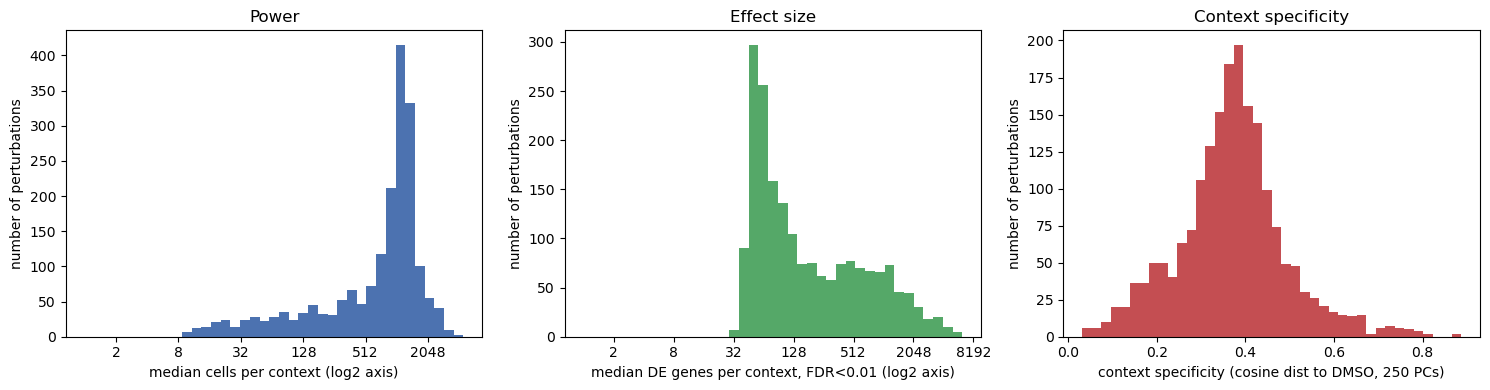

In [7]:
# ===== Distributions of the three axes (median per context, log2 axes) ==
from matplotlib.ticker import ScalarFormatter
core = feat.dropna(subset=["n_cells_median_ctx", "nDE_median_ctx", "context_specificity"])

def _log2_axis(ax, axis="x"):
    if "x" in axis:
        ax.set_xscale("log", base=2); ax.xaxis.set_major_formatter(ScalarFormatter())
    if "y" in axis:
        ax.set_yscale("log", base=2); ax.yaxis.set_major_formatter(ScalarFormatter())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
b_cells = np.logspace(0, np.log2(core["n_cells_median_ctx"].max()), 40, base=2)
axes[0].hist(core["n_cells_median_ctx"].clip(lower=1), bins=b_cells, color="#4c72b0")
_log2_axis(axes[0]); axes[0].set_xlabel("median cells per context (log2 axis)"); axes[0].set_title("Power")

b_de = np.logspace(0, np.log2(core["nDE_median_ctx"].max()), 40, base=2)
axes[1].hist(core["nDE_median_ctx"].clip(lower=1), bins=b_de, color="#55a868")
_log2_axis(axes[1]); axes[1].set_xlabel(f"median DE genes per context, FDR<{FDR_THRESH} (log2 axis)"); axes[1].set_title("Effect size")

axes[2].hist(core["context_specificity"], bins=40, color="#c44e52")
axes[2].set_xlabel(f"context specificity (cosine dist to DMSO, {CONTEXT_SPEC_NPCS} PCs)")
axes[2].set_title("Context specificity")
for ax in axes: ax.set_ylabel("number of perturbations")
plt.tight_layout(); plt.show()

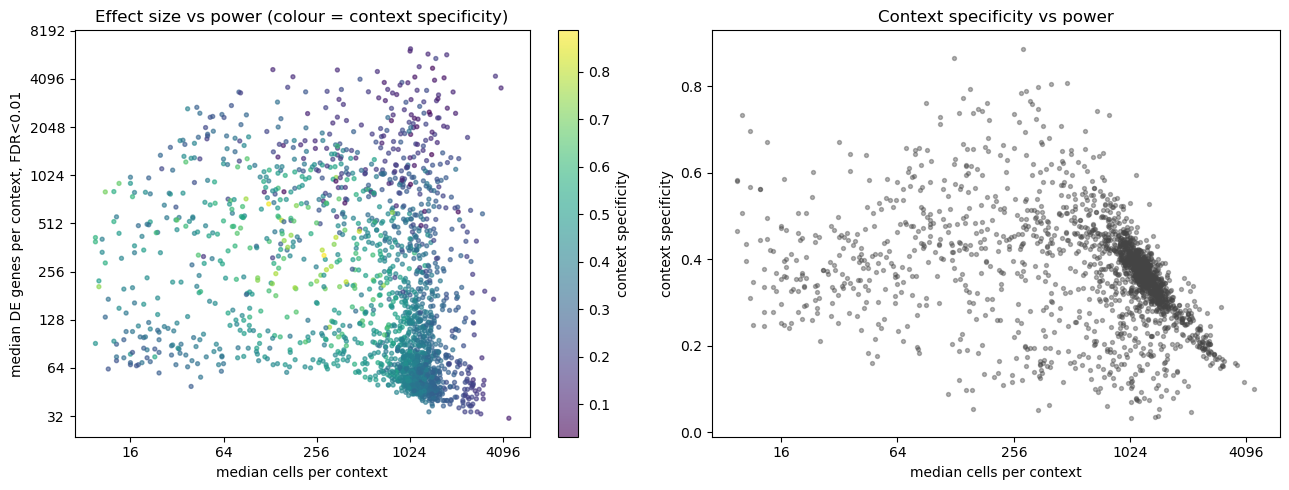

Spearman correlations (genes with all features):
                     n_cells_median_ctx  nDE_median_ctx  context_specificity
n_cells_median_ctx                 1.00           -0.43                -0.46
nDE_median_ctx                    -0.43            1.00                -0.10
context_specificity               -0.46           -0.10                 1.00


In [8]:
# ===== Relationships between the three axes (median, log2 axes) =========
from matplotlib.ticker import ScalarFormatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc0 = axes[0].scatter(core["n_cells_median_ctx"].clip(lower=1), core["nDE_median_ctx"].clip(lower=1),
                      c=core["context_specificity"], cmap="viridis", s=8, alpha=0.6)
axes[0].set_xscale("log", base=2); axes[0].set_yscale("log", base=2)
axes[0].xaxis.set_major_formatter(ScalarFormatter()); axes[0].yaxis.set_major_formatter(ScalarFormatter())
axes[0].set_xlabel("median cells per context")
axes[0].set_ylabel(f"median DE genes per context, FDR<{FDR_THRESH}")
axes[0].set_title("Effect size vs power (colour = context specificity)")
fig.colorbar(sc0, ax=axes[0], label="context specificity")

axes[1].scatter(core["n_cells_median_ctx"].clip(lower=1), core["context_specificity"],
                s=8, alpha=0.4, color="#444")
axes[1].set_xscale("log", base=2); axes[1].xaxis.set_major_formatter(ScalarFormatter())
axes[1].set_xlabel("median cells per context"); axes[1].set_ylabel("context specificity")
axes[1].set_title("Context specificity vs power")
plt.tight_layout(); plt.show()

print("Spearman correlations (genes with all features):")
print(core[["n_cells_median_ctx", "nDE_median_ctx", "context_specificity"]].corr(method="spearman").round(2))

In [9]:
# ===== Combine ALL extracted features into one feature matrix ===========
import anndata as ad

# perturbation universe = ALL profiled genes (union), incl. those without a context-spec score
genes_cl = sorted(set(cells_per_drug.index) | set(de_per_drug.index) | set(ctx.index))

cells_block = cells_per_drug.reindex(genes_cl).fillna(0.0)
cells_block.columns = [f"cells__{c}" for c in cells_block.columns]       # per-drug cell counts (power)
de_block = de_per_drug.reindex(genes_cl).fillna(0.0)                     # per-drug # DE genes (not tested -> 0)
de_block.columns = [f"nDE__{c}" for c in de_block.columns]
ctx_block = ctx["context_specificity"].reindex(genes_cl).to_frame("context_specificity")
# genes lacking a context-spec score: impute with the mean so they sit at ~0 after z-scoring
# (neutral contribution) rather than being dropped from the clustering.
_n_missing = int(ctx_block["context_specificity"].isna().sum())
ctx_block["context_specificity"] = ctx_block["context_specificity"].fillna(
    ctx_block["context_specificity"].mean())
print(f"context specificity imputed (mean) for {_n_missing} genes lacking a score")

Xfeat = pd.concat([cells_block, de_block, ctx_block], axis=1)
print("combined feature matrix:", Xfeat.shape,
      f"(perturbations x features: {cells_block.shape[1]} cells + {de_block.shape[1]} nDE + 1 ctx-spec)")
Xfeat.head()

context specificity imputed (mean) for 559 genes lacking a score
combined feature matrix: (2478, 34) (perturbations x features: 16 cells + 17 nDE + 1 ctx-spec)


,cells__AR-A014418,cells__AZD4573,cells__Bisindolylmaleimide-I,cells__CHIR-98014,cells__DG-172,cells__DMSO_round2,cells__DMSO_round2_batch2,cells__JTE-607,cells__LDN-193189,cells__LY2090314,...,nDE__JTE-607,nDE__LDN-193189,nDE__LY2090314,nDE__Lexibulin,nDE__NSC95397,nDE__PP121,nDE__Romidepsin,nDE__Stattic,nDE__VX-11e,context_specificity
gene,,,,,,,,,,,,,,,,,,,,,
A1BG,2540,2611,2782,2804,2958,2089,2166,2123,3232,2874,...,59.0,30.0,53.0,36.0,54.0,41.0,48.0,42.0,52.0,0.158987
AASS,923,925,961,962,1055,659,659,719,999,1034,...,76.0,110.0,84.0,113.0,102.0,92.0,84.0,119.0,66.0,0.430958
AATF,0,1,0,0,0,0,1,4,1,0,...,90.0,62.0,0.0,0.0,65.0,0.0,36.0,161.0,0.0,0.370151
ABCB6,1442,1437,1621,1662,1921,1117,1134,1197,1820,1744,...,91.0,51.0,1382.0,54.0,99.0,45.0,71.0,111.0,49.0,0.352582
ABCC5,1086,1159,1182,1384,1394,863,903,668,1441,1223,...,92.0,44.0,64.0,62.0,70.0,62.0,70.0,56.0,48.0,0.383520


In [10]:
Xfeat.columns

Index(['cells__AR-A014418', 'cells__AZD4573', 'cells__Bisindolylmaleimide-I',
       'cells__CHIR-98014', 'cells__DG-172', 'cells__DMSO_round2',
       'cells__DMSO_round2_batch2', 'cells__JTE-607', 'cells__LDN-193189',
       'cells__LY2090314', 'cells__Lexibulin', 'cells__NSC95397',
       'cells__PP121', 'cells__Romidepsin', 'cells__Stattic', 'cells__VX-11e',
       'nDE__AR-A014418', 'nDE__AZD4573', 'nDE__Bisindolylmaleimide-I',
       'nDE__CHIR-98014', 'nDE__DG-172', 'nDE__DMSO', 'nDE__DMSO_round2',
       'nDE__DMSO_round2_batch2', 'nDE__JTE-607', 'nDE__LDN-193189',
       'nDE__LY2090314', 'nDE__Lexibulin', 'nDE__NSC95397', 'nDE__PP121',
       'nDE__Romidepsin', 'nDE__Stattic', 'nDE__VX-11e',
       'context_specificity'],
      dtype='object')

In [11]:
# ===== AnnData -> scale -> PCA -> kNN -> Leiden ========================
adf = ad.AnnData(X=Xfeat.to_numpy(dtype="float32"))
adf.obs_names = Xfeat.index
adf.var_names = Xfeat.columns
adf.layers["raw_features"] = adf.X.copy()

sc.pp.scale(adf)                                       # z-score each feature (scales differ wildly)
sc.tl.pca(adf, n_comps=min(10, adf.n_vars - 1))
sc.pp.neighbors(adf, n_neighbors=N_NEIGHBORS, use_rep="X_pca")
sc.tl.leiden(adf, resolution=LEIDEN_RES, key_added="leiden")
sc.tl.umap(adf)

print("Leiden clusters (resolution=%.2f):" % LEIDEN_RES)
print(adf.obs["leiden"].value_counts().sort_index())

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_2981122/1525817156.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adf, resolution=LEIDEN_RES, key_added="leiden")


Leiden clusters (resolution=1.00):
leiden
0     218
1     214
2     207
3     191
4     180
5     178
6     154
7     137
8     133
9     123
10    121
11    108
12    104
13    100
14     96
15     96
16     76
17     42
Name: count, dtype: int64


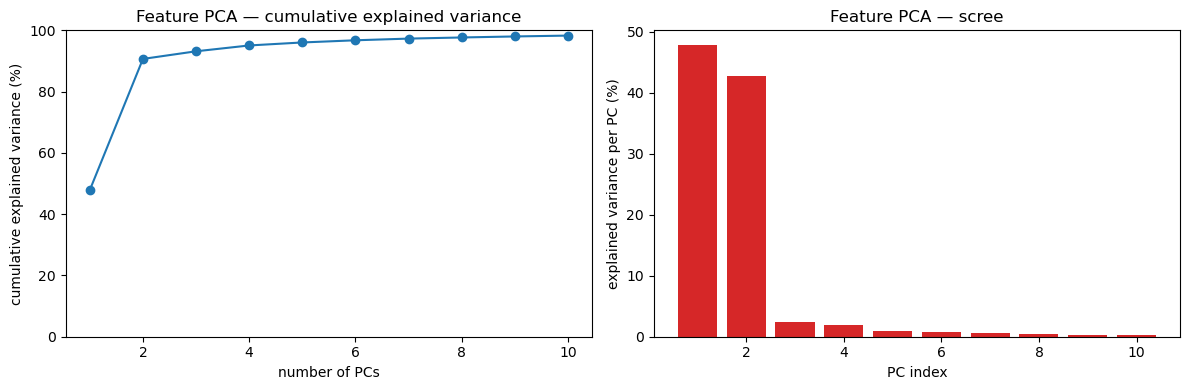

   1 PCs ->  47.9% cumulative
   2 PCs ->  90.7% cumulative
   3 PCs ->  93.2% cumulative
   4 PCs ->  95.1% cumulative
   5 PCs ->  96.0% cumulative
   6 PCs ->  96.8% cumulative
   7 PCs ->  97.3% cumulative
   8 PCs ->  97.7% cumulative
   9 PCs ->  98.0% cumulative
  10 PCs ->  98.3% cumulative


In [12]:
# ---- Explained variance of the feature PCA vs # PCs -------------------
vr  = adf.uns["pca"]["variance_ratio"]
pcs = np.arange(1, len(vr) + 1)
cum = np.cumsum(vr) * 100.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pcs, cum, "o-", color="#1f77b4")
axes[0].set_xlabel("number of PCs"); axes[0].set_ylabel("cumulative explained variance (%)")
axes[0].set_title("Feature PCA — cumulative explained variance"); axes[0].set_ylim(0, 100)
axes[1].bar(pcs, vr * 100.0, color="#d62728")
axes[1].set_xlabel("PC index"); axes[1].set_ylabel("explained variance per PC (%)")
axes[1].set_title("Feature PCA — scree")
plt.tight_layout(); plt.show()

for k in pcs:
    print(f"  {k:>2d} PCs -> {cum[k-1]:5.1f}% cumulative")

In [13]:
# ===== Attach clusters to the feature table + cluster profiles =========
feat["leiden"] = pd.Series(adf.obs["leiden"].values, index=adf.obs_names).reindex(feat.index)
feat.to_csv(os.path.join(OUT_DIR, "perturbation_features.csv"))
adf.write_h5ad(os.path.join(OUT_DIR, "perturbation_feature_clusters.h5ad"))
print("saved:", os.path.join(OUT_DIR, "perturbation_feature_clusters.h5ad"))

# median of the interpretable summary features per cluster
profile_cols = ["n_cells_median_ctx", "nDE_median_ctx", "context_specificity",
                "n_sig_contexts", "n_contexts_present"]
print("\nCluster medians (summary features):")
print(feat.dropna(subset=["leiden"]).groupby("leiden")[profile_cols].median().round(2))

saved: /home/beraslan/Projects/ChemoGeneticScreens/TextFiles/perturbation_feature_clusters.h5ad

Cluster medians (summary features):
        n_cells_median_ctx  nDE_median_ctx  context_specificity  \
leiden                                                            
0                     3.00          104.50                 0.37   
1                  1392.25           58.00                 0.33   
2                    73.00          444.00                 0.52   
3                  1228.00           57.50                 0.36   
4                   769.50           81.00                 0.46   
5                  1011.50           59.00                 0.40   
6                     1.00           92.75                  NaN   
7                  2331.50           60.00                 0.22   
8                  1303.50          461.50                 0.30   
9                   660.00          408.00                 0.44   
10                  180.00           94.00                 0.45

/tmp/ipykernel_2981122/60659048.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(feat.dropna(subset=["leiden"]).groupby("leiden")[profile_cols].median().round(2))


## Stratified train / val / test perturbation split

Assign every perturbation to **train (25%) / val (5%) / test (70%)** by random sampling **within each Leiden cluster** (so each cluster is represented in the same proportions). Saved with the features + `leiden` to `perturbation_train_val_test_split.csv`.

In [14]:
# ===== Stratified train/val/test split within Leiden clusters ==========
SPLIT_FRACS = {"val": 0.05, "test": 0.70, "train": 0.25}   # 5% / 70% / 25%
SPLIT_SEED  = 0
_rng = np.random.default_rng(SPLIT_SEED)

split = pd.Series(index=feat.index, dtype=object)
for _cl, _idx in feat.groupby("leiden").groups.items():
    g = np.array(list(_idx))
    g = g[_rng.permutation(len(g))]                 # shuffle genes within the cluster
    n = len(g)
    n_val  = int(round(SPLIT_FRACS["val"]  * n))
    n_test = int(round(SPLIT_FRACS["test"] * n))
    split.loc[g[:n_val]]                 = "val"
    split.loc[g[n_val:n_val + n_test]]   = "test"
    split.loc[g[n_val + n_test:]]        = "train"   # remainder -> train (~25%)

feat["split"] = split
# order rows by leiden, then split (train -> val -> test)
_split_order = pd.CategoricalDtype(["train", "val", "test"], ordered=True)
feat = feat.sort_values(["leiden", "split"],
                        key=lambda s: s.astype(_split_order) if s.name == "split" else s)
split_path = os.path.join(OUT_DIR, "perturbation_train_val_test_split.csv")
feat.to_csv(split_path)
print("wrote", split_path, feat.shape)
print("overall:", feat["split"].value_counts(normalize=True).round(3).to_dict(),
      feat["split"].value_counts().to_dict())
# sanity: per-cluster fractions
print(feat.groupby("leiden")["split"].value_counts(normalize=True).unstack().round(2).to_string())

wrote /home/beraslan/Projects/ChemoGeneticScreens/TextFiles/perturbation_train_val_test_split.csv (2478, 9)
overall: {'test': 0.701, 'train': 0.249, 'val': 0.05} {'test': 1736, 'train': 617, 'val': 125}
split   test  train   val
leiden                   
0       0.70   0.25  0.05
1       0.70   0.25  0.05
2       0.70   0.25  0.05
3       0.70   0.25  0.05
4       0.70   0.25  0.05
5       0.70   0.25  0.05
6       0.70   0.25  0.05
7       0.70   0.25  0.05
8       0.70   0.25  0.05
9       0.70   0.25  0.05
10      0.70   0.25  0.05
11      0.70   0.25  0.05
12      0.70   0.25  0.05
13      0.70   0.25  0.05
14      0.70   0.25  0.05
15      0.70   0.25  0.05
16      0.70   0.25  0.05
17      0.69   0.26  0.05


/tmp/ipykernel_2981122/1138489857.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _cl, _idx in feat.groupby("leiden").groups.items():
/tmp/ipykernel_2981122/1138489857.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(feat.groupby("leiden")["split"].value_counts(normalize=True).unstack().round(2).to_string())


In [15]:
feat

,n_cells_median_ctx,n_contexts_present,nDE_mean_ctx,nDE_median_ctx,nDE_max_ctx,n_sig_contexts,context_specificity,leiden,split
gene,,,,,,,,,
A1BG,2717.5,16,47.647059,46.0,90.0,17,0.158987,7,train
AASS,943.0,16,94.117647,92.0,135.0,17,0.430958,4,test
AATF,1.0,7,84.142857,86.0,161.0,7,NaN,6,test
ABCB6,1629.0,16,223.470588,71.0,1418.0,17,0.352582,8,test
ABCC5,1170.5,16,60.705882,61.0,92.0,17,0.383520,13,test
...,...,...,...,...,...,...,...,...,...
ZSCAN29,1340.0,16,48.352941,47.0,76.0,17,NaN,1,train
ZSCAN32,349.5,16,1873.235294,1557.0,6195.0,17,0.601716,12,train
ZW10,37.5,16,2076.352941,2667.0,3623.0,17,0.403774,12,test


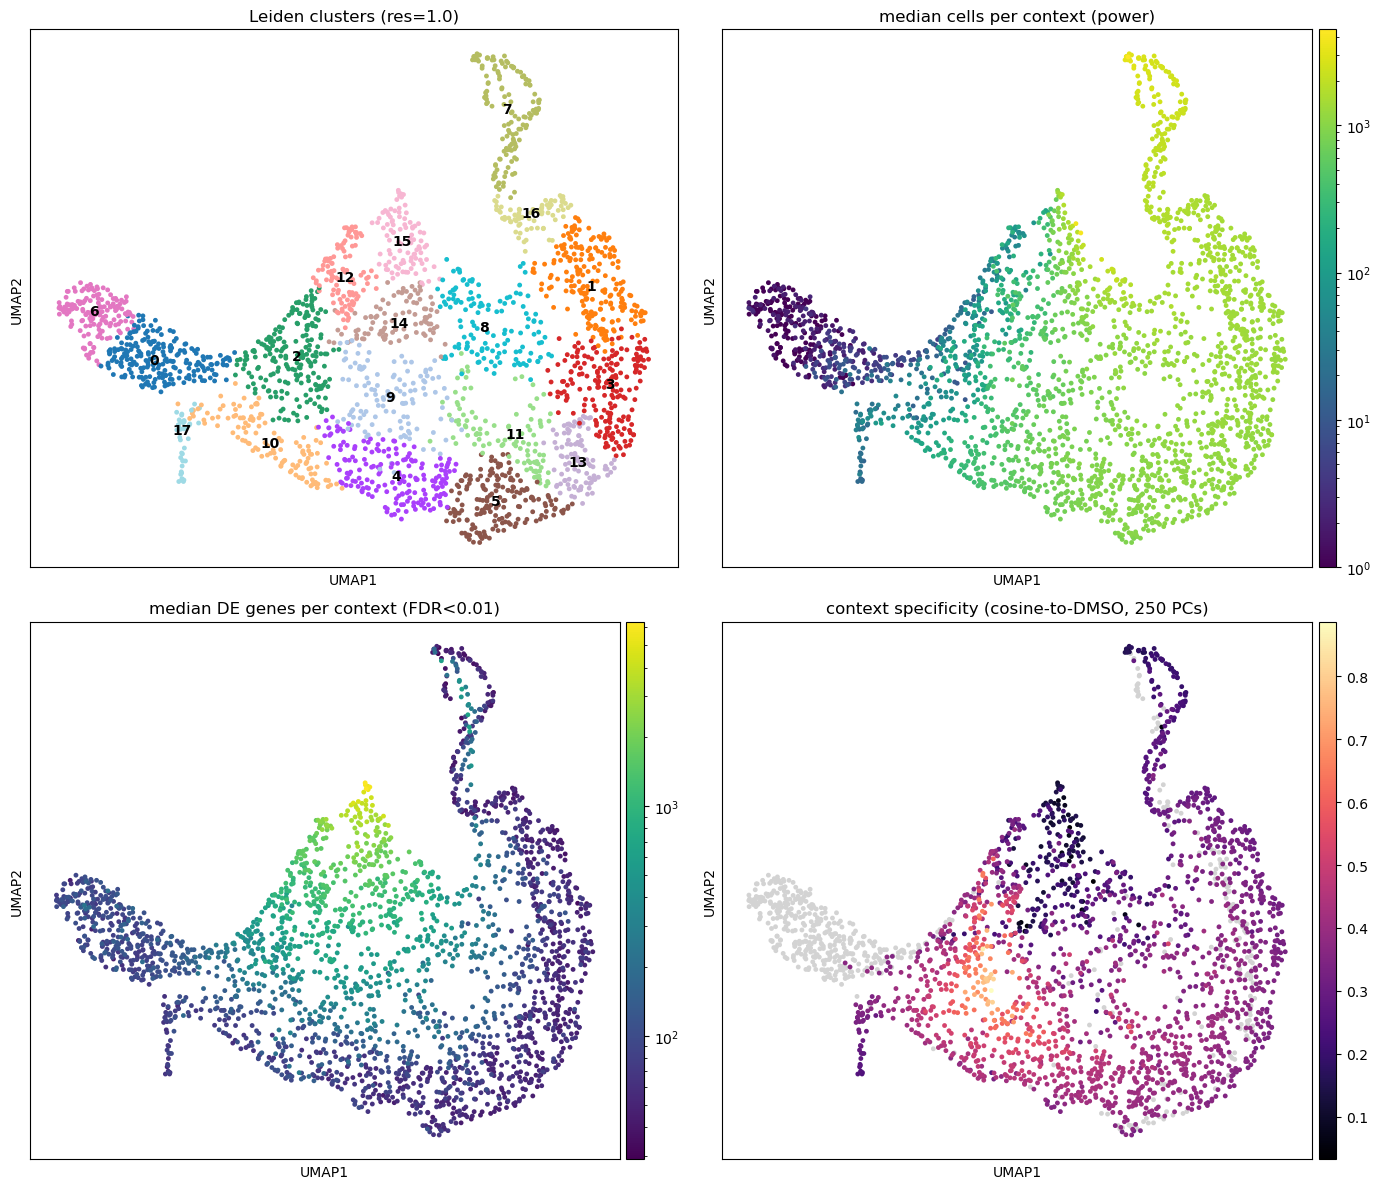

In [16]:
# ===== Visualise clusters + feature gradients on the UMAP =============
# Colour by per-context MEDIAN features on a LOG colour scale that shows the
# natural counts (LogNorm) so the colourbar is easy to read. Context specificity
# is a per-gene score (linear); genes lacking it render in na_color (grey).
from matplotlib.colors import LogNorm
adf.obs["n_cells_median"] = feat["n_cells_median_ctx"].reindex(adf.obs_names).clip(lower=1).to_numpy()
adf.obs["nDE_median"]     = feat["nDE_median_ctx"].reindex(adf.obs_names).clip(lower=1).to_numpy()
# obs key must differ from the var "context_specificity" (a feature column) to avoid a name clash
adf.obs["context_specificity_raw"] = feat["context_specificity"].reindex(adf.obs_names).to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sc.pl.umap(adf, color="leiden", ax=axes[0, 0], show=False, legend_loc="on data",
           title=f"Leiden clusters (res={LEIDEN_RES})")
sc.pl.umap(adf, color="n_cells_median", ax=axes[0, 1], show=False, cmap="viridis",
           norm=LogNorm(vmin=max(1.0, np.nanmin(adf.obs["n_cells_median"])),
                        vmax=float(np.nanmax(adf.obs["n_cells_median"]))),
           title="median cells per context (power)")
sc.pl.umap(adf, color="nDE_median", ax=axes[1, 0], show=False, cmap="viridis",
           norm=LogNorm(vmin=max(1.0, np.nanmin(adf.obs["nDE_median"])),
                        vmax=float(np.nanmax(adf.obs["nDE_median"]))),
           title=f"median DE genes per context (FDR<{FDR_THRESH})")
sc.pl.umap(adf, color="context_specificity_raw", ax=axes[1, 1], show=False, cmap="magma",
           title="context specificity (cosine-to-DMSO, 250 PCs)")
plt.tight_layout()
plt.savefig(os.path.join(projectDir, "PerturbationEmbeddings", "perturbation_feature_clusters_umap.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Outputs & notes

- `TextFiles/perturbation_cells_per_drug.csv` — genes × drug contexts, cell counts (power).
- `TextFiles/perturbation_nDE_fdr_lt_0p01_per_drug.csv` — genes × drug contexts, # DE genes (FDR<0.01).
- `TextFiles/perturbation_cosine_to_DMSO_per_drug.csv` — genes × 14 drug contexts, cosine distance to batch-matched DMSO (250 PCs), per context.
- `TextFiles/perturbation_nDE_and_cosine_per_context.csv` — **tidy per-(perturbation × drug context) table**: `gene`, `drug_context`, `nDE_fdr_lt_0.01`, `cosine_to_matched_DMSO`.
- `TextFiles/perturbation_context_specificity.csv` — per gene, `context_specificity` (mean cosine distance to batch-matched DMSO, 250 PCs).
- `TextFiles/perturbation_features.csv` — **combined per-perturbation table** (power, effect-size, context
  specificity summaries) + `leiden` cluster label.
- `TextFiles/perturbation_feature_clusters.h5ad` — AnnData of the combined feature matrix with PCA/UMAP/Leiden.
- `TextFiles/perturbation_train_val_test_split.csv` — features + `leiden` + `split` (train 25% / val 5% / test 70%, stratified within Leiden clusters, seed 0).
- `PerturbationEmbeddings/perturbation_feature_clusters_umap.png` — UMAP coloured by cluster and by each feature.

**Definitions used**
- Power: `n_cells_total` (sum across drug contexts); also median per present context and # contexts present.
- Effect size: `nDE_total` / `nDE_mean_ctx` / `nDE_max_ctx` (# response genes with FDR<0.01), and
  `n_sig_contexts` (# contexts with ≥1 DE gene).
- Context specificity: mean cosine distance between each `(drug, gene)` signature and the gene's
  batch-matched DMSO baseline, over non-DMSO contexts, at 250 PCs (notebook 23 / 18). The
  **per-context** (non-averaged) cosine distances are in `perturbation_nDE_and_cosine_per_context.csv`.

**Note (read before splitting):** context specificity is now the cosine-distance-to-batch-matched-DMSO
score at 250 PCs (notebook 23, where the score stabilises). Check the printed Spearman correlations for
how it co-varies with power and effect size, and treat it conditional on adequate power/effect size when
diversifying the test set.

**Clustering:** all extracted features are combined into one matrix (per-drug cell counts + per-drug #DE genes + context specificity), wrapped in AnnData, z-scored, then PCA → 15-NN → Leiden. Note the matrix is dominated by the per-drug columns (~16 cells + ~17 nDE) vs the single context-specificity column; up-weight or cluster on the summary features instead if you want context specificity to carry more weight.